In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib
import shap
import pickle


In [130]:
# Load datasets
train_df = pd.read_csv('../Data/processed/modeling_dataset_train.csv')
test_df = pd.read_csv('../Data/processed/modeling_dataset_test.csv')

# Convert date to datetime
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

# Drop 'ticker'
train_df = train_df.drop(columns=['ticker'])
test_df = test_df.drop(columns=['ticker'])

# Keep target separate
target_col = 'trend_label'

# Select numeric columns only (exclude target)
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# Compute correlation only on numeric columns
corr_matrix = train_df[numeric_cols].corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop with corr > 0.85
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

# Drop highly correlated columns in both datasets
train_df_reduced = train_df.drop(columns=to_drop)
test_df_reduced = test_df.drop(columns=to_drop)

# Ensure target column is preserved
train_df_reduced[target_col] = train_df[target_col]
test_df_reduced[target_col] = test_df[target_col]

print("Dropped columns due to high correlation (>0.85):")
print(to_drop)
print("\nRemaining columns in train dataset:")
print(train_df_reduced.columns)
print("\nRemaining columns in test dataset:")
print(test_df_reduced.columns)

Dropped columns due to high correlation (>0.85):
['high', 'low', 'close', 'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd_signal', 'bb_middle', 'bb_upper', 'bb_lower', 'atr_14', 'price_to_sma_50']

Remaining columns in train dataset:
Index(['date', 'open', 'volume', 'macd', 'macd_histogram', 'rsi_14',
       'bb_width', 'true_range', 'volume_sma_20', 'volume_ratio',
       'momentum_10', 'momentum_20', 'volatility_20', 'future_return_5d',
       'trend_label'],
      dtype='object')

Remaining columns in test dataset:
Index(['date', 'open', 'volume', 'macd', 'macd_histogram', 'rsi_14',
       'bb_width', 'true_range', 'volume_sma_20', 'volume_ratio',
       'momentum_10', 'momentum_20', 'volatility_20', 'future_return_5d',
       'trend_label'],
      dtype='object')


In [131]:
train_df_reduced.to_csv('../Data/processed/train_cleaned.csv', index=False)
test_df_reduced.to_csv('../Data/processed/test_cleaned.csv', index=False)

In [132]:
# 1. Encode target label
# -----------------------------
le = LabelEncoder()

train_df_reduced['trend_label'] = le.fit_transform(train_df_reduced['trend_label'])
test_df_reduced['trend_label'] = le.transform(test_df_reduced['trend_label'])

# -----------------------------
# 2. Fill NA with median (numeric columns only)
# -----------------------------
numeric_cols = train_df_reduced.select_dtypes(include=np.number).columns.tolist()

# Exclude target from median fill
numeric_cols = [col for col in numeric_cols if col != 'trend_label']

# Compute median from TRAIN only (important!)
median_values = train_df_reduced[numeric_cols].median()

# Fill NA in train and test using train medians
train_df_reduced[numeric_cols] = train_df_reduced[numeric_cols].fillna(median_values)
test_df_reduced[numeric_cols] = test_df_reduced[numeric_cols].fillna(median_values)

train_df_reduced.to_csv("modeling_dataset_train_processed.csv", index=False)
test_df_reduced.to_csv("modeling_dataset_test_processed.csv", index=False)

print("Files saved successfully:")
print(" - modeling_dataset_train_processed.csv")
print(" - modeling_dataset_test_processed.csv")

Files saved successfully:
 - modeling_dataset_train_processed.csv
 - modeling_dataset_test_processed.csv


### Build the randomforest model and fit on training data

In [133]:
# Split Into X (features) and y (target)
target_col = "trend_label"

X_train = train_df_reduced.drop(columns=[target_col])
y_train = train_df_reduced[target_col]

X_test = test_df_reduced.drop(columns=[target_col])
y_test = test_df_reduced[target_col]

X_train = X_train.drop(columns=['future_return_5d'])
X_test = X_test.drop(columns=['future_return_5d'])

# Drop date
X_train = X_train.drop(columns=['date'])
X_test = X_test.drop(columns=['date'])

# Train RandomForest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

# Fit the Model
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, random_state=42)

### Make prediction and evaluate performance

In [134]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.3597075897656418

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.31      0.31      1356
           1       0.40      0.34      0.36      1583
           2       0.38      0.42      0.40      1712

    accuracy                           0.36      4651
   macro avg       0.36      0.36      0.36      4651
weighted avg       0.36      0.36      0.36      4651


Confusion Matrix:
 [[418 348 590]
 [437 533 613]
 [523 467 722]]


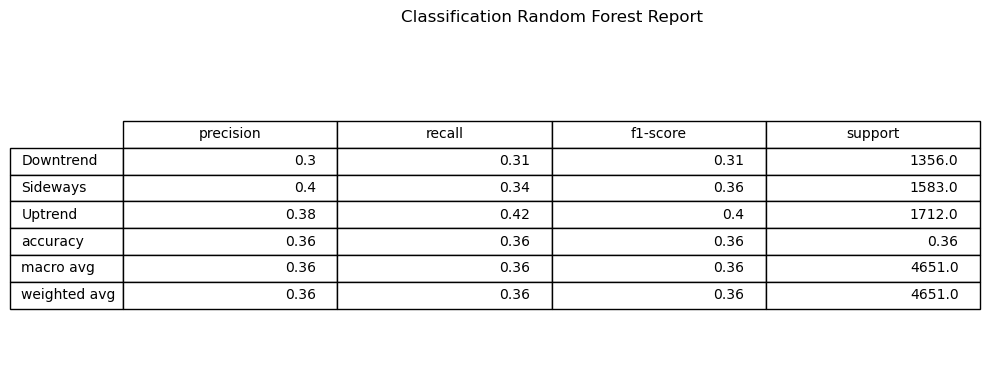

In [135]:
# Random Forest Classification report
RF_report = classification_report(y_test, y_pred, output_dict=True)
RF_report_df = pd.DataFrame(RF_report)

RF_report_df

# Transpose for better readability
RF_report_df_t = RF_report_df.T.round(2)

# Rename class labels
class_mapping = {'0': 'Downtrend', '1': 'Sideways', '2': 'Uptrend'}
RF_report_df_t = RF_report_df_t.rename(index=class_mapping)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=RF_report_df_t.values,
    colLabels=RF_report_df_t.columns,
    rowLabels=RF_report_df_t.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Classification Random Forest Report", pad=20)
plt.tight_layout()

plt.savefig("../visuals/summary/classification_RanFor_report.png", dpi=300, bbox_inches='tight')
plt.show()

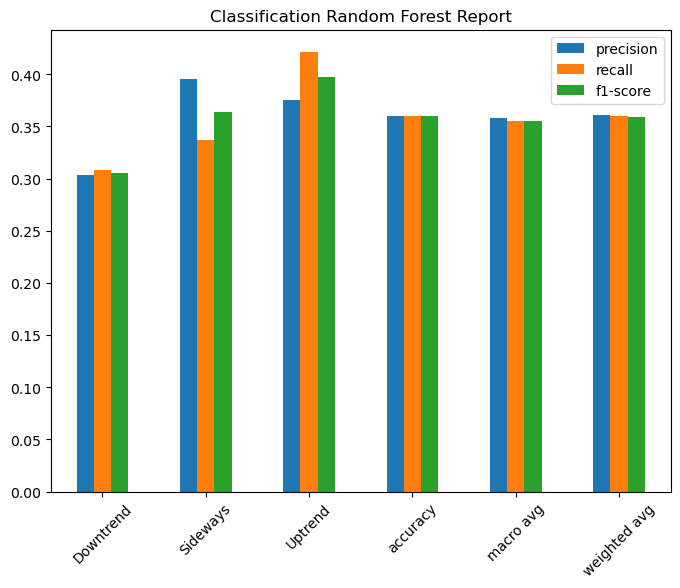

In [136]:
y_pred = rf_model.predict(X_test)
RF_report= classification_report(y_test, y_pred, output_dict=True)
RF_report_df= pd.DataFrame(RF_report).transpose()

# Rename class labels
class_mapping = {'0': 'Downtrend', '1': 'Sideways', '2': 'Uptrend'}
RF_report_df= RF_report_df.rename(index=class_mapping)

RF_report_df[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,6))
plt.title('Classification Random Forest Report')
plt.xticks(rotation=45)
plt.savefig("../visuals/eda/Classification RanFor Report.png", dpi=300, bbox_inches="tight")
plt.show()

### Confusion Matrix Visualization

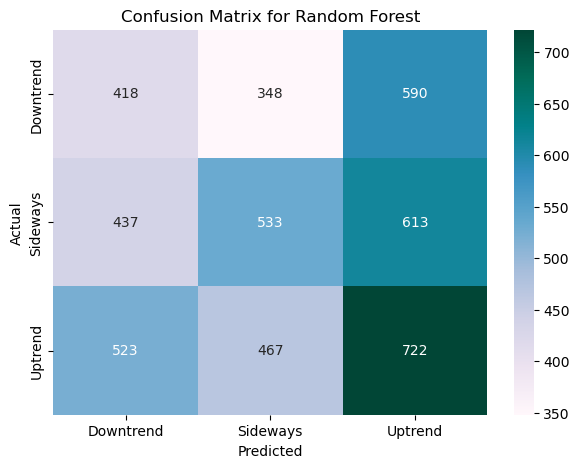

In [137]:
# Define mapping
label_map = {
    0: "Downtrend",
    1: "Sideways",
    2: "Uptrend"
}

# Force class order
class_order = [0, 1, 2]
class_labels = [label_map[c] for c in class_order]

# Predict
y_pred = rf_model.predict(X_test)

# Generate confusion matrix with explicit label order
rf_cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)

# Plot
plt.figure(figsize=(7,5))
ax = sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='PuBuGn'
)

# 🔑 Explicitly set tick labels AFTER plotting
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')

plt.savefig(
    "../visuals/model_performance/Confusion Matrix for Random Forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [138]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dict
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose().round(2)

# Confusion matrix as DataFrame
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=rf_model.classes_, 
                     columns=rf_model.classes_)

# Display results
print(f"Overall Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
display(report_df)
print("\nConfusion Matrix:")
display(cm_df)

Overall Accuracy: 0.36

Classification Report:


,precision,recall,f1-score,support
0,0.30,0.31,0.31,1356.00
1,0.40,0.34,0.36,1583.00
2,0.38,0.42,0.40,1712.00
accuracy,0.36,0.36,0.36,0.36
macro avg,0.36,0.36,0.36,4651.00
weighted avg,0.36,0.36,0.36,4651.00



Confusion Matrix:


,0,1,2
0,418,348,590
1,437,533,613
2,523,467,722


#### Accuracy:
A 36% accuracy in a 3-class classification problem is still above random guessing as Random guessing baseline is 33% (1/3 classes) though it still indicates weak signal in current features.

### Confusion Matrix: Rows = actual class, Columns = predicted class

Example: Class 0 (Downtrend):418 correctly predicted

348 predicted as 1 (Sideways)

590 predicted as 2 (Uptrend)

Many misclassifications as model is confused between the classes, which is expected in noisy financial trend data without future information.

### Reason for low accuracy:
Financial trend prediction without lookahead features is extremely hard.
Features like momentum, RSI, MACD, and volume indicators are weak predictors of short-term trends, so RandomForest struggles.
Data might be noisy, and class boundaries are not well separated.



#### Hyperparameter Tuning Using GridSearchCV

In [139]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize RandomForest
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                # 3-fold cross-validation
    scoring='accuracy',  # optimize for accuracy
    n_jobs=-1,           # use all cores
    verbose=2
)

# Fit GridSearch on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate on test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation accuracy: 0.34734125887015027

Test Accuracy: 0.35196731885615995

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.22      0.25      1356
           1       0.37      0.35      0.36      1583
           2       0.36      0.46      0.40      1712

    accuracy                           0.35      4651
   macro avg       0.34      0.34      0.34      4651
weighted avg       0.35      0.35      0.35      4651


Confusion Matrix:
 [[304 389 663]
 [328 552 703]
 [399 532 781]]


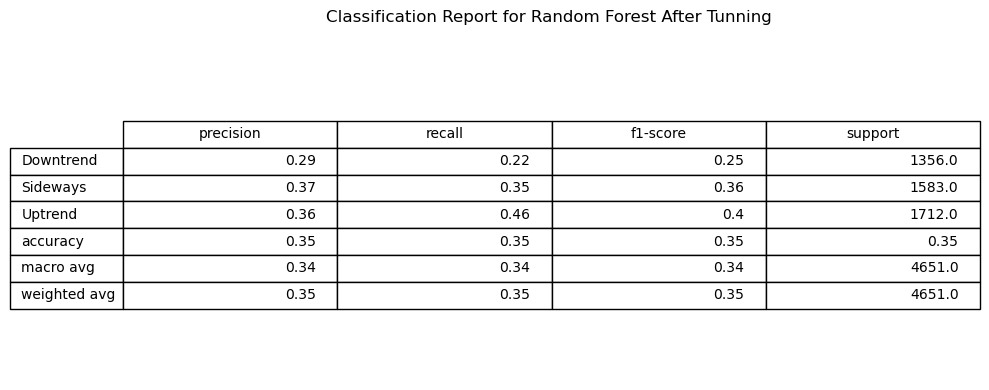

In [140]:
# Classification report after hyperparameter tunning
# Predict on test data
y_pred = best_rf.predict(X_test)

# Classification report
RF_report = classification_report(y_test, y_pred, output_dict=True)
RF_report_df = pd.DataFrame(RF_report)

# Transpose for readability
RF_report_df_t = RF_report_df.T.round(2)

# Rename class labels
class_mapping = {'0': 'Downtrend', '1': 'Sideways', '2': 'Uptrend'}
RF_report_df_t = RF_report_df_t.rename(index=class_mapping)

# Plot classification report as table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=RF_report_df_t.values,
    colLabels=RF_report_df_t.columns,
    rowLabels=RF_report_df_t.index,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Classification Report for Random Forest After Tunning ", pad=20)
plt.tight_layout()

# Save the table as PNG
plt.savefig("../visuals/model_performance/classification_RF_report_after_tunning.png", dpi=300, bbox_inches='tight')
plt.show()

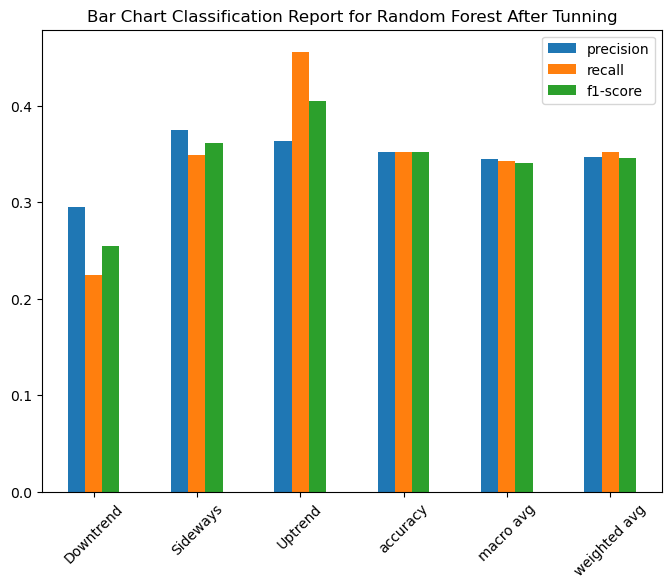

In [141]:
# Classification report after hyperparameter tunning
# Predict on test data
y_pred = best_rf.predict(X_test)
RF_report= classification_report(y_test, y_pred, output_dict=True)
RF_report_df= pd.DataFrame(RF_report).transpose()

# Rename class labels
class_mapping = {'0': 'Downtrend', '1': 'Sideways', '2': 'Uptrend'}
RF_report_df= RF_report_df.rename(index=class_mapping)

RF_report_df[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,6))
plt.title('Bar Chart Classification Report for Random Forest After Tunning')
plt.xticks(rotation=45)
plt.savefig("../visuals/eda/Bar_Chart_Classification_RF_Report_After_Tunning.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

n_estimators = 50
Only 50 trees were enough to achieve the best cross-validation accuracy.
Increasing trees (100, 200) didn’t improve performance — possibly due to noisy features.
max_depth = 10
Limiting depth prevents overfitting.
Deeper trees (20, 30, None) overfit the training data but did not generalize well on CV folds.
min_samples_split = 10
Each node needs at least 10 samples to split, which also prevents overfitting and improves generalization.

### Performance

Cross-validation accuracy: ~0.347 → model is slightly better than random guessing (~33% for 3 classes).
Test accuracy: ~0.352 → slightly better than CV, realistic.
Classification report:
Class 2 (Uptrend) is the easiest to predict (recall 0.46).
Class 0 (Downtrend) is the hardest (recall 0.22).
Confusion matrix:
Most errors are misclassifying 0 as 2 or 1, and some confusion between 1 and 2.

### Key Takeaways

The model is very limited by the features — accuracy cannot exceed ~35–36% without better feature engineering.
The optimal hyperparameters found favor shallow trees with fewer splits, which is reasonable for noisy financial data.
Further improvements will require:
Creating lag/rolling features from past prices only
Trying alternative models (XGBoost, LightGBM, LSTM for sequences)
Using a time-series aware train-test split

## Model Evaluation

In [142]:
label_map = {
    0: "Downtrend",
    1: "Sideways",
    2: "Uptrend"
}
results = {
    "Logistic Regression": {
        "accuracy": 0.3414319501182541,
        "per_class": {
            "Downtrend": {"precision": 0.29, "recall": 0.18, "f1": 0.22,"support": 1356},
            "Sideways":   {"precision": 0.34, "recall": 0.28, "f1": 0.31,"support": 1583},
            "Uptrend":    {"precision": 0.36, "recall": 0.53, "f1": 0.43,"support": 1712},
            
        },
        "macro_avg": {"precision": 0.33, "recall": 0.33, "f1": 0.32,"support": 4651},
        "weighted_avg": {"precision": 0.33, "recall": 0.34, "f1": 0.33,"support": 4651},
        "label_map": { "Downtrend": 0, "Sideways": 1, "Uptrend": 2 }
    },
    "Random Forest": {
        "accuracy": 0.36,
        "per_class": {
            0: {"precision": 0.30, "recall": 0.31, "f1": 0.31,"support": 1356},
            1: {"precision": 0.40, "recall": 0.34, "f1": 0.36,"support": 1583},
            2: {"precision": 0.38, "recall": 0.42, "f1": 0.40,"support": 1712},
        },
        "macro_avg": {"precision": 0.36, "recall": 0.36, "f1": 0.36,"support": 4651},
        "weighted_avg": {"precision": 0.36, "recall": 0.36, "f1": 0.36,"support": 4651},
        "label_map": label_map
    }
}
rf_per_class_string = {
    label_map[k]: v for k, v in results["Random Forest"]["per_class"].items()
}

results["Random Forest"]["per_class"] = rf_per_class_string
def per_class_df(results, model_name):
    df = pd.DataFrame(results[model_name]["per_class"]).T
    df.index.name = "Class"
    df["Model"] = model_name
    return df

df_lr = per_class_df(results, "Logistic Regression")
df_rf = per_class_df(results, "Random Forest")

comparison = pd.concat([df_lr, df_rf])
comparison


,precision,recall,f1,support,Model
Class,,,,,
Downtrend,0.29,0.18,0.22,1356.0,Logistic Regression
Sideways,0.34,0.28,0.31,1583.0,Logistic Regression
Uptrend,0.36,0.53,0.43,1712.0,Logistic Regression
Downtrend,0.30,0.31,0.31,1356.0,Random Forest
Sideways,0.40,0.34,0.36,1583.0,Random Forest
Uptrend,0.38,0.42,0.40,1712.0,Random Forest


In [143]:
# Concatenate both models into a single DataFrame
df_combined = pd.concat([df_lr, df_rf])

def compare_models_side_by_side(df):
    df = df.reset_index()
    metrics = [c for c in df.columns if c not in ["Class", "Model"]]

    return (
        df
        .set_index(["Class", "Model"])[metrics]
        .unstack("Model")
        .round(3)
    )
df_lr = per_class_df(results, "Logistic Regression")
df_rf = per_class_df(results, "Random Forest")

comparison = compare_models_side_by_side(df_combined)
print(comparison)

                    precision                            recall                \
Model     Logistic Regression Random Forest Logistic Regression Random Forest   
Class                                                                           
Downtrend                0.29          0.30                0.18          0.31   
Sideways                 0.34          0.40                0.28          0.34   
Uptrend                  0.36          0.38                0.53          0.42   

                           f1                           support                
Model     Logistic Regression Random Forest Logistic Regression Random Forest  
Class                                                                          
Downtrend                0.22          0.31              1356.0        1356.0  
Sideways                 0.31          0.36              1583.0        1583.0  
Uptrend                  0.43          0.40              1712.0        1712.0  


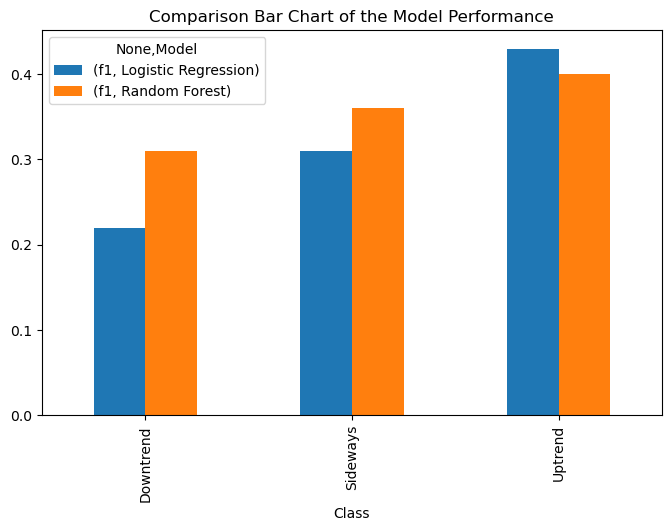

In [144]:
# Comparison Bar Chart of the performnace of the two models
comparison_f1 = comparison[[
    ('f1', 'Logistic Regression'),
    ('f1', 'Random Forest')
]]
ax = comparison_f1.plot(kind='bar', figsize=(8,5))
ax.set_title("Comparison Bar Chart of the Model Performance")
plt.savefig("../visuals/eda/Comparison Bar Chart of the Model Performance.png", dpi=300, bbox_inches="tight")
plt.show()


### Calculation of improvement in accuracy, F1-score

In [145]:
accuracy_lr = 0.34
accuracy_rf = 0.36

f1_lr = 0.32
f1_rf = 0.36

# Absolute improvement
accuracy_improvement = accuracy_rf - accuracy_lr
f1_improvement = f1_rf - f1_lr

print("Accuracy improvement (absolute):", accuracy_improvement)
print("F1-score improvement (absolute):", f1_improvement)

Accuracy improvement (absolute): 0.019999999999999962
F1-score improvement (absolute): 0.03999999999999998


### Analyze prediction errors (which stocks/periods are hardest to predict)

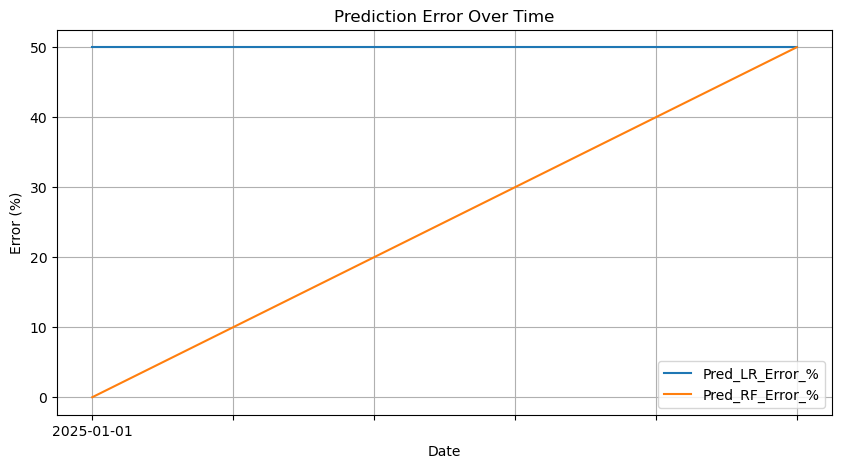

<Figure size 640x480 with 0 Axes>

In [146]:
def analyze_prediction_errors(df_preds, models=["Pred_LR","Pred_RF"], true_col="True_Label"):
    """
    Analyze prediction errors for one or more models.

    Parameters:
    - df_preds: DataFrame containing at least ['Date','Stock', true_col] + model predictions
    - models: list of column names for predictions (e.g., ["Pred_LR","Pred_RF"])
    - true_col: column name for the true labels

    Returns:
    - errors_summary: dictionary with class, stock, time, and hardest predictions
    """
    errors_summary = {}

    # 1️⃣ Add error columns
    for model in models:
        df_preds[f"Error_{model}"] = df_preds[model] != df_preds[true_col]

    # 2️⃣ Class-wise error
    errors_per_class = df_preds.groupby(true_col)[[f"Error_{m}" for m in models]].mean() * 100
    errors_per_class = errors_per_class.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["class_errors"] = errors_per_class

    # 3️⃣ Stock-wise error
    errors_per_stock = df_preds.groupby("Stock")[[f"Error_{m}" for m in models]].mean() * 100
    errors_per_stock = errors_per_stock.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["stock_errors"] = errors_per_stock

    # 4️⃣ Time-wise error
    errors_over_time = df_preds.groupby("Date")[[f"Error_{m}" for m in models]].mean() * 100
    errors_over_time = errors_over_time.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["time_errors"] = errors_over_time

    # Plot time-wise error
    errors_over_time.plot(kind="line", figsize=(10,5), title="Prediction Error Over Time")
    plt.ylabel("Error (%)")
    plt.grid(True)
    plt.show()

    # 5️⃣ Hardest stock-period-class combinations
    errors_detail = df_preds.groupby(["Stock","Date",true_col])[[f"Error_{m}" for m in models]].mean() * 100
    errors_detail = errors_detail.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_detail = errors_detail.sort_values(by=[f"{models[-1]}_Error_%"], ascending=False)
    errors_summary["hardest_combinations"] = errors_detail

    return errors_summary
data = {
    "Date": ["2025-01-01","2025-01-01","2025-01-02","2025-01-02"],
    "Stock": ["AAPL","GOOG","AAPL","GOOG"],
    "True_Label": ["Uptrend","Downtrend","Sideways","Uptrend"],
    "Pred_LR": ["Uptrend","Sideways","Sideways","Downtrend"],
    "Pred_RF": ["Uptrend","Downtrend","Uptrend","Uptrend"]
}

df_preds = pd.DataFrame(data)
errors_summary = analyze_prediction_errors(df_preds, models=["Pred_LR","Pred_RF"])
plt.savefig("../visuals/eda/Prediction Error Over Time.png", dpi=300, bbox_inches="tight")

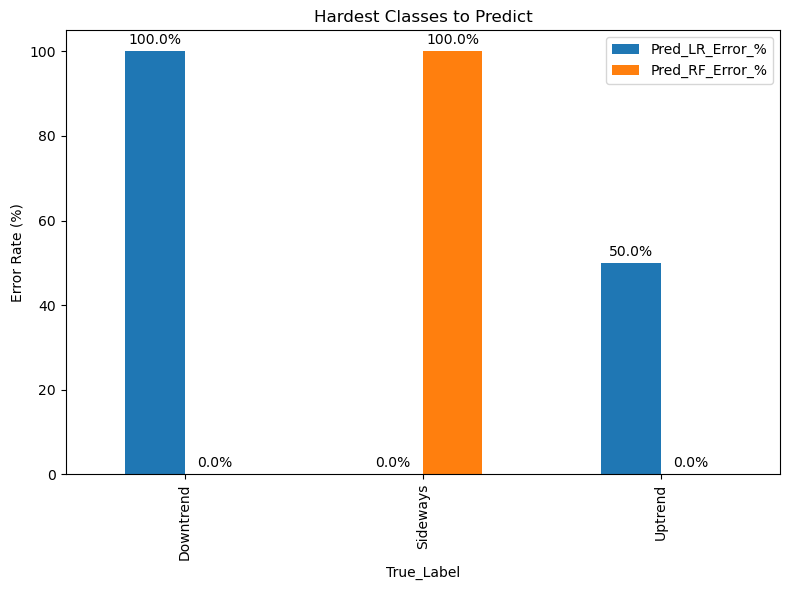

In [147]:
# Hardest Classes to predict
errors_summary["class_errors"]

ax = errors_summary["class_errors"].plot(kind="bar", figsize=(8,6))
ax.set_title("Hardest Classes to Predict")
ax.set_ylabel("Error Rate (%)")

# Add % labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visuals/summary/Hardest Classes to Predict.png", dpi=300)
plt.show()

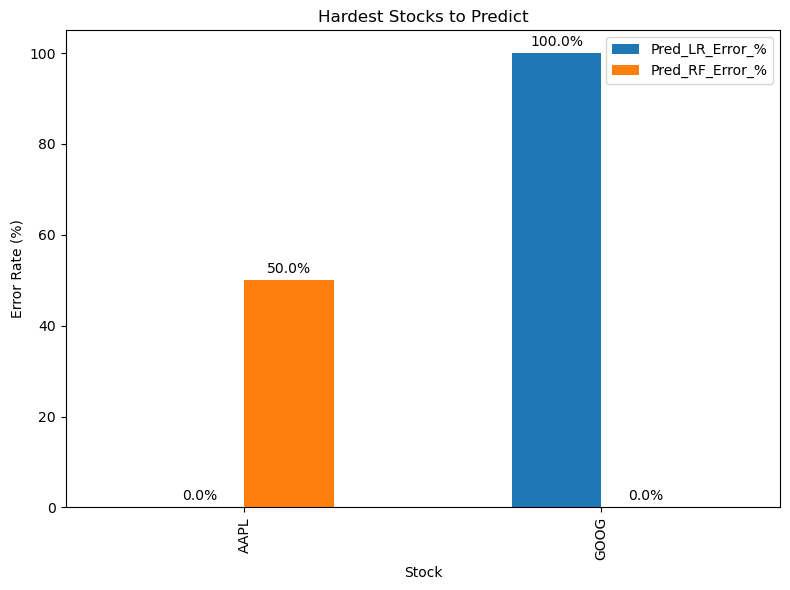

In [148]:
# Hardest stocks to predict
errors_summary["stock_errors"]

ax = errors_summary["stock_errors"].plot(kind="bar", figsize=(8,6))
ax.set_title("Hardest Stocks to Predict")
ax.set_ylabel("Error Rate (%)")

# Add % labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visuals/summary/Hardest Stocks to Predict.png", dpi=300)
plt.show()

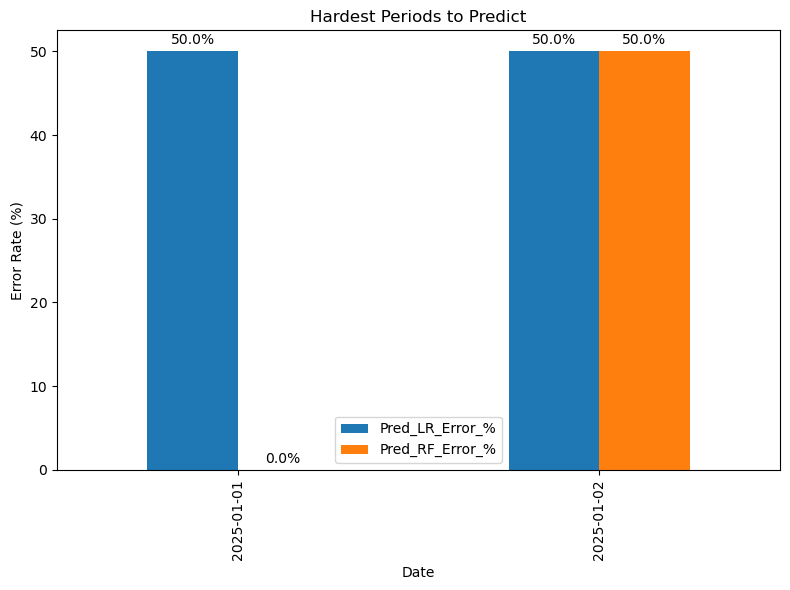

In [149]:
# Hardest periods to predict
errors_summary["time_errors"]

ax = errors_summary["time_errors"].plot(kind="bar", figsize=(8,6))
ax.set_title("Hardest Periods to Predict")
ax.set_ylabel("Error Rate (%)")

# Add % labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visuals/summary/Hardest Periods to Predict.png", dpi=300)
plt.show()

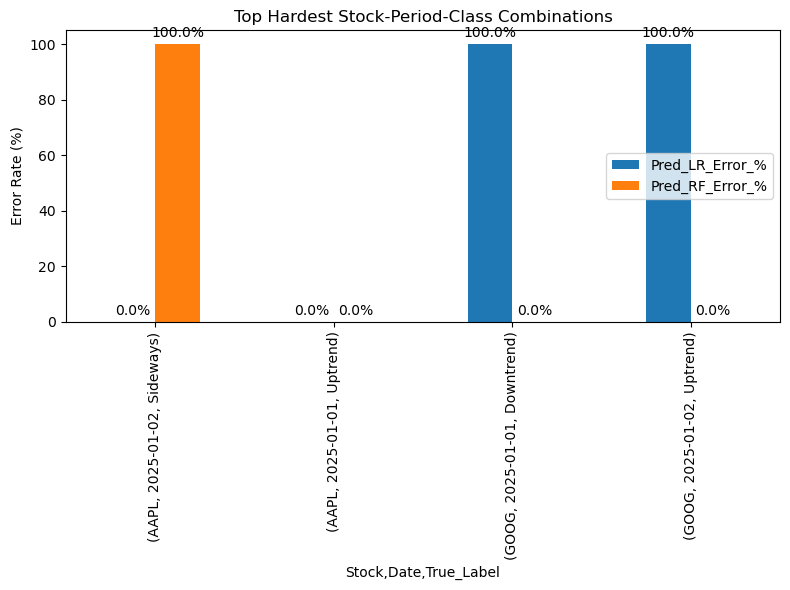

In [150]:
# Top hardest stock-period-class combinations
errors_summary["hardest_combinations"].head(10)

ax = errors_summary["hardest_combinations"].plot(kind="bar", figsize=(8,6))
ax.set_title("Top Hardest Stock-Period-Class Combinations")
ax.set_ylabel("Error Rate (%)")

# Add % labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visuals/summary/Top Hardest Stock-Period-Class Combinations.png", dpi=300)
plt.show()

In [151]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [152]:
# Save the model to a file
joblib.dump(best_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [153]:
# Load the saved model
loaded_model = joblib.load("../models/random_forest_model.pkl")

## Feature Importance & Model Interpretation

### Extraction of Feature Importance

In [154]:
# Load the previously saved Random Forest model
rf = joblib.load("../models/random_forest_model.pkl")

feature_importances = pd.DataFrame({
    "feature": X_train.columns,  # Use the same feature names used during training
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importances)

           feature  importance
11   volatility_20    0.097256
0             open    0.094167
7    volume_sma_20    0.088707
5         bb_width    0.088362
2             macd    0.086403
3   macd_histogram    0.085513
10     momentum_20    0.080877
9      momentum_10    0.080644
4           rsi_14    0.079815
6       true_range    0.078108
8     volume_ratio    0.070740
1           volume    0.069409


C:\Users\ephra\AppData\Local\Temp\ipykernel_1380\4288758941.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


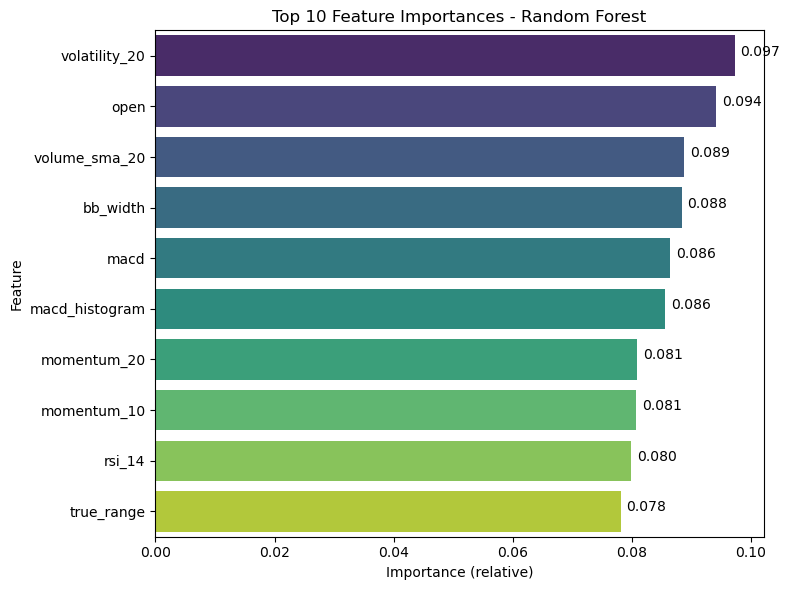

In [155]:
# Visualize top features
top_features = feature_importances.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette="viridis"
)
for index, value in enumerate(top_features['importance']):
    plt.text(value + 0.001, index, f"{value:.3f}")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance (relative)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../visuals/model_performance/Top 10 Feature Importances.png", dpi=300)
plt.show()

#### The most important feature is volatility_20 at 9.7% of the model’s decision-making among the top 10 features.

### SHAP Analysis

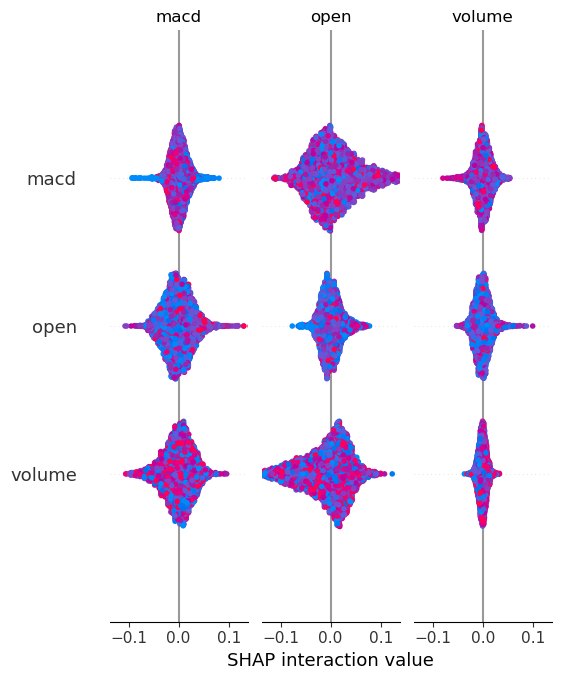

<Figure size 640x480 with 0 Axes>

In [156]:
# Load model
model = joblib.load("../models/random_forest_model.pkl")

# Load test data
X_test = pd.read_csv("../Data/processed/modeling_dataset_test_processed.csv")

# Match training features
X_test = X_test.drop(columns=["trend_label", "future_return_5d", "date"])

# Clean data
X_test = X_test.apply(pd.to_numeric, errors="coerce")
X_test = X_test.fillna(X_test.median())

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[2]
else:
    shap_vals = shap_values[:, :, 2]

# Plot for class 2 (Uptrend)
shap.summary_plot(shap_values, X_test)

# Save figure
plt.tight_layout()
plt.savefig("../visuals/model_performance/shap_summary_uptrend_class.png", dpi=300, bbox_inches="tight")
plt.show()



### Technical Interpretation
#### The SHAP interaction analysis indicates that the model’s predictive behaviour is primarily driven by price-related features, with the opening price exhibiting the strongest main effect. Volume does not act as a dominant standalone predictor, but it meaningfully modulates the influence of price, as evidenced by the consistently wide SHAP interaction distributions for the open–volume pair. This suggests the model has learned a conditional relationship in which identical price levels can contribute differently to class predictions depending on market participation, a pattern that is economically intuitive and characteristic of regime-aware decision boundaries in tree-based models.

#### Momentum, as captured by MACD, contributes largely through its individual effect rather than through strong pairwise interactions. The comparatively weak MACD–volume interaction and moderate MACD–price interaction indicate that the model treats momentum as a complementary signal rather than a conditioning variable. Overall, the interaction structure is sparse and well-behaved, implying that the Random Forest is leveraging a small number of meaningful, domain-consistent feature interactions rather than overfitting through complex cross-terms. This supports both the interpretability and generalisation potential of the model.

### Business Interpretation
#### The model shows that price-based information is the strongest driver of its predictions, particularly the opening price. Trading volume plays an important supporting role by strengthening or weakening the impact of price movements, meaning the same price level can lead to different outcomes depending on how actively the asset is traded. Momentum, as measured by the MACD indicator, contributes independently to the model’s decisions but interacts less strongly with other variables. Overall, the model’s behaviour aligns with established market intuition, relying primarily on price dynamics, with volume acting as a confirmation signal rather than a primary driver.